In [1]:
from ultralytics import YOLO
import torch
import os
import cv2
import glob
import random
import matplotlib.pyplot as plt
from PIL import Image


In [18]:
print("Установка успешна?", torch.__version__)
print("Доступен ли CUDA (GPU)?", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Ваша видеокарта:", torch.cuda.get_device_name(0))
    print("Версия CUDA внутри Torch:", torch.version.cuda)

Установка успешна? 2.12.0+cu130
Доступен ли CUDA (GPU)? True
Ваша видеокарта: NVIDIA GeForce RTX 4070 Ti SUPER
Версия CUDA внутри Torch: 13.0


In [155]:
model = YOLO('yolo11x.pt') 

In [2]:
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

In [3]:
torch.cuda.empty_cache()

In [156]:
results = model.train(
    data='/home/vitaliy/Desktop/elbrus bootcamp/phase_2/projeckt_1/data.yaml',
    epochs=25,       # Полноценные 40 эпох
    imgsz=800,       # Размер изображений
    batch=16,        # Уменьшили батч с 32 до 16 для предотвращения OOM
    workers=8,       # Оставляем параллельную загрузку процессором
    device=0,        # Ваша видеокарта
    amp=True         # Включаем автоматическое смешивание точности для экономии памяти
)

Ultralytics 8.4.60 🚀 Python-3.13.12 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4070 Ti SUPER, 15921MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/vitaliy/Desktop/elbrus bootcamp/phase_2/projeckt_1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-28, nbs=64, nms=False, opset=None, opt

найдено лиц для маскировки 4


(np.float64(-0.5), np.float64(744.5), np.float64(1023.5), np.float64(-0.5))

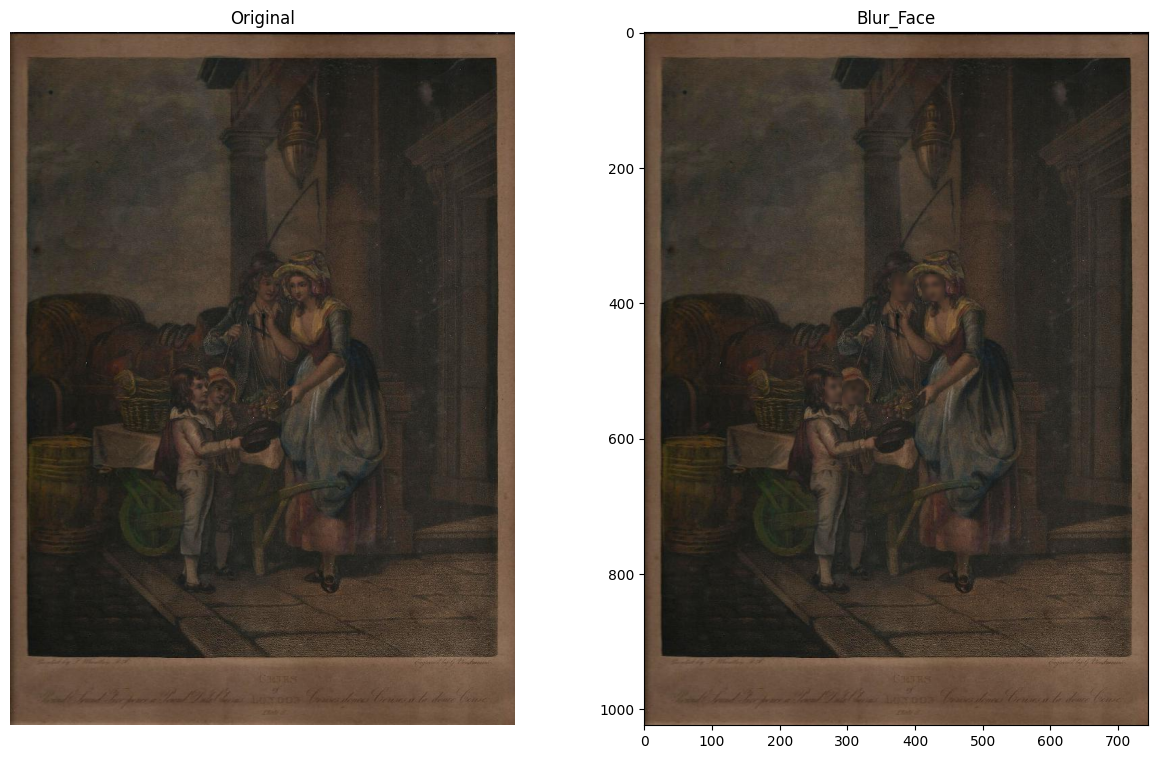

In [168]:
%matplotlib inline
model = YOLO('/home/vitaliy/runs/detect/train-28/weights/best.pt')

val_image = '/home/vitaliy/Desktop/elbrus bootcamp/phase_2/projeckt_1/face-detection-dataset/images/val'
all_val_img = glob.glob(os.path.join(val_image, '*'))
test_img_path = random.choice(all_val_img)
img_bgr = cv2.imread(test_img_path)
anon_img = img_bgr.copy()

res = model.predict(source=test_img_path, conf=0.30, imgsz=800, device=0, verbose=False)[0]
if len(res.boxes) == 0:
    print("Face on this image not found")
else:
    print(f'найдено лиц для маскировки {len(res.boxes)}')

    for box in res.boxes:
        x1,y1,x2,y2 = map(int, box.xyxy[0].tolist())
        face_roi = anon_img[y1:y2, x1:x2]
        if face_roi.shape[0] == 0 or face_roi.shape[1] == 0:
            continue
        ksize_x = int(face_roi.shape[1] * 0.4) | 1
        ksize_y = int(face_roi.shape[0] * 0.4) | 1

        blur_face = cv2.GaussianBlur(face_roi, (ksize_x, ksize_y), 0)
        anon_img[y1:y2, x1:x2] = blur_face

img_orig_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_anon_rgb = cv2.cvtColor(anon_img, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1,2,figsize=(15,9))
axes[0].imshow(img_orig_rgb)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_anon_rgb)
axes[1].set_title('Blur_Face')
axes[0].axis('off')
        